In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re

In [2]:
df = pd.read_csv('../data/complaints.csv')

C:\Users\mijuu\AppData\Local\Temp\ipykernel_17352\1500743720.py:1: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/complaints.csv')


In [3]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Date received                 str  
 1   Product                       str  
 2   Sub-product                   str  
 3   Issue                         str  
 4   Sub-issue                     str  
 5   Consumer complaint narrative  str  
 6   Company public response       str  
 7   Company                       str  
 8   State                         str  
 9   ZIP code                      str  
 10  Tags                          str  
 11  Consumer consent provided?    str  
 12  Submitted via                 str  
 13  Date sent to company          str  
 14  Company response to consumer  str  
 15  Timely response?              str  
 16  Consumer disputed?            str  
 17  Complaint ID                  int64
dtypes: int64(1), str(17)
memory usage: 1.3 GB


In [5]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='str')

In [6]:
df.shape

(9609797, 18)

In [7]:
df.isnull().sum()

Date received                         0
Product                               0
Sub-product                      235295
Issue                                 6
Sub-issue                        839522
Consumer complaint narrative    6629041
Company public response         4770207
Company                               0
State                             54516
ZIP code                          30228
Tags                            8981029
Consumer consent provided?      1649561
Submitted via                         0
Date sent to company                  0
Company response to consumer         20
Timely response?                      0
Consumer disputed?              8841498
Complaint ID                          0
dtype: int64

In [9]:
product_counts = df["Product"].value_counts()

print(product_counts)

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

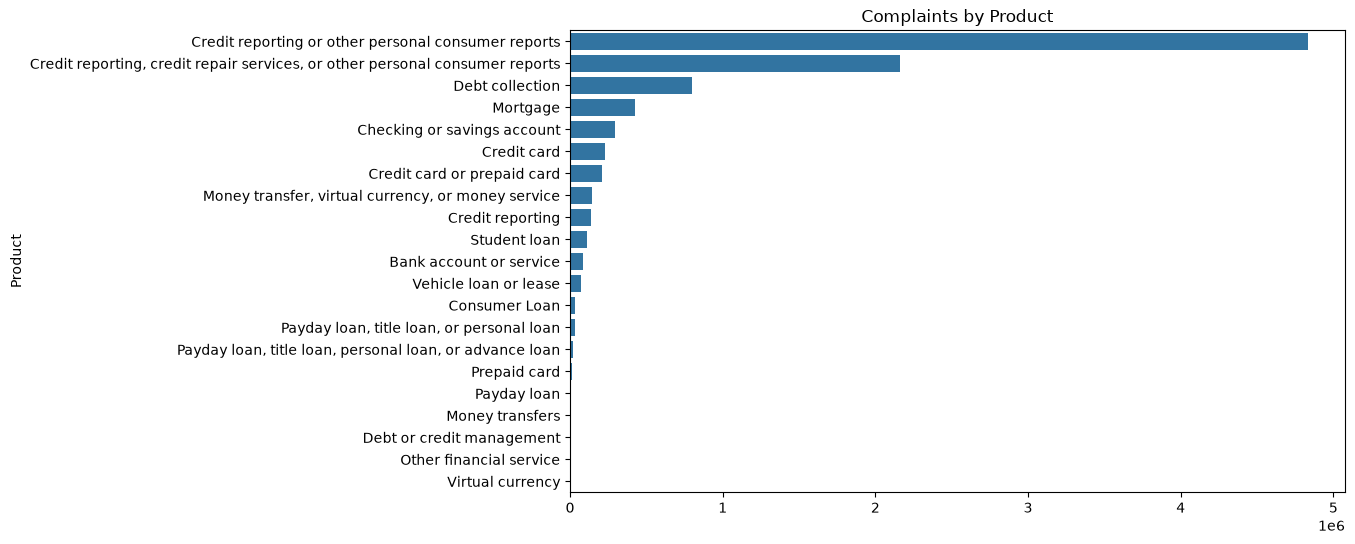

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=product_counts.values,
    y=product_counts.index
)

plt.title("Complaints by Product")
plt.show()

complaint narrative length 

In [11]:
df["narrative_length"] = (
    df["Consumer complaint narrative"]
    .fillna("")
    .apply(lambda x: len(x.split()))
)

In [12]:
df["narrative_length"].describe()

count    9.609797e+06
mean     5.446667e+01
std      1.497672e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: narrative_length, dtype: float64

In [25]:
df["Product"].unique()

<StringArray>
[                         'Credit reporting or other personal consumer reports',
                                                              'Debt collection',
                                                                  'Credit card',
                                                  'Checking or savings account',
                           'Money transfer, virtual currency, or money service',
                                                        'Vehicle loan or lease',
                                                    'Debt or credit management',
                                                                     'Mortgage',
                      'Payday loan, title loan, personal loan, or advance loan',
                                                                 'Prepaid card',
                                                                 'Student loan',
                                                             'Credit reporting',
 'Credit repor

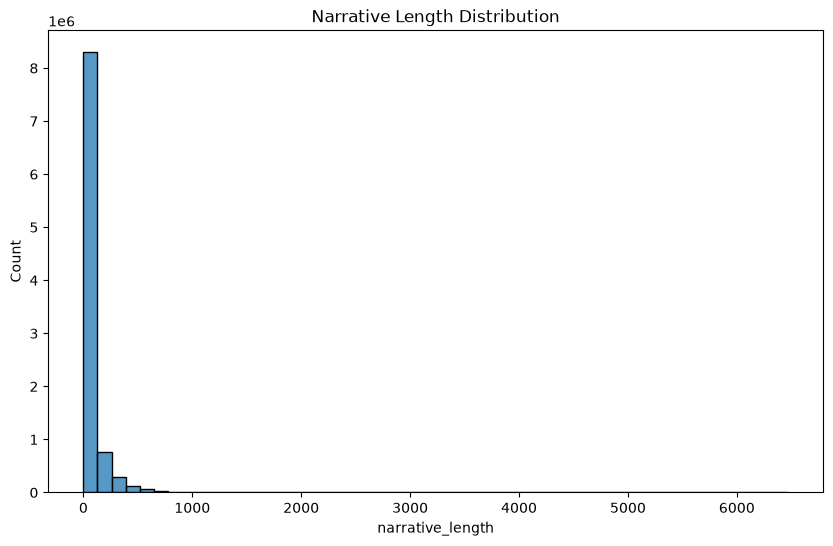

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["narrative_length"],
    bins=50
)

plt.title("Narrative Length Distribution")
plt.show()

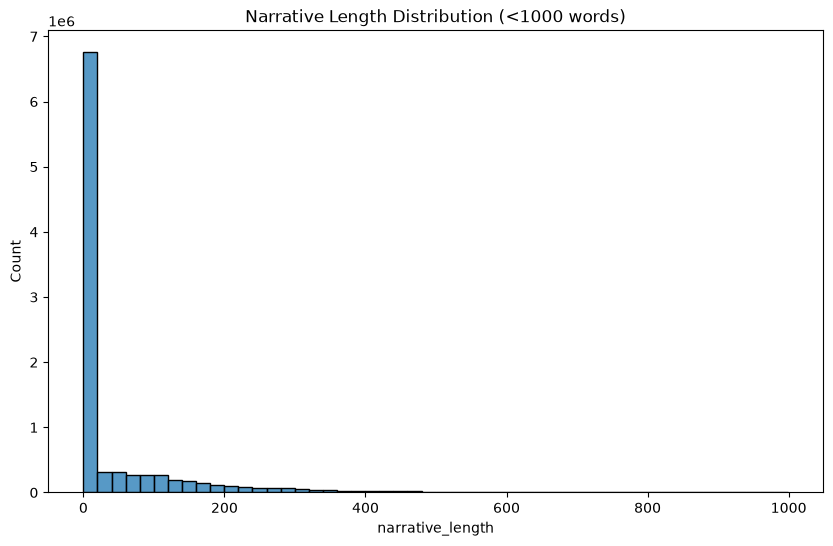

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    df[df["narrative_length"] < 1000]["narrative_length"],
    bins=50
)

plt.title("Narrative Length Distribution (<1000 words)")
plt.show()

Missing Narratives

In [16]:
narrative_col = "Consumer complaint narrative"

with_narrative = df[narrative_col].notna().sum()

without_narrative = df[narrative_col].isna().sum()

print("With narrative:", with_narrative)
print("Without narrative:", without_narrative)

With narrative: 2980756
Without narrative: 6629041


<Axes: >

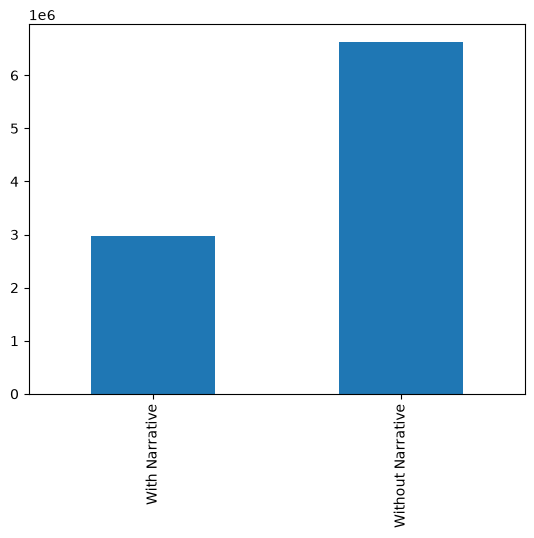

In [17]:
pd.Series({
    "With Narrative": with_narrative,
    "Without Narrative": without_narrative
}).plot(kind="bar")

In [18]:
narrative_df = df[
    df["Consumer complaint narrative"].notna()
]

In [28]:
narrative_df["narrative_length"] = (
    narrative_df["Consumer complaint narrative"]
    .apply(lambda x: len(str(x).split()))
)

narrative_df["narrative_length"].describe()

count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
Name: narrative_length, dtype: float64

In [20]:
target_products = [
    "Credit card",
    "Credit card or prepaid card",

    "Checking or savings account",

    "Money transfer, virtual currency, or money service",
    "Money transfers",

    "Consumer Loan",
    "Payday loan, title loan, or personal loan",
    "Payday loan, title loan, personal loan, or advance loan"
]

In [29]:
filtered_df = narrative_df[
    narrative_df["Product"].isin(target_products)
].copy()

In [30]:
filtered_df["Consumer complaint narrative"].isna().sum()

np.int64(0)

In [31]:
filtered_df["narrative_length"] = (
    filtered_df["Consumer complaint narrative"]
    .apply(lambda x: len(x.split()))
)

In [32]:
filtered_df["narrative_length"].describe()

count    463933.000000
mean        205.036303
std         227.137225
min           1.000000
25%          82.000000
50%         136.000000
75%         254.000000
max        6469.000000
Name: narrative_length, dtype: float64

In [33]:
filtered_df["Product"].value_counts()

Product
Checking or savings account                                140319
Credit card or prepaid card                                108667
Money transfer, virtual currency, or money service          97188
Credit card                                                 80667
Payday loan, title loan, or personal loan                   17238
Consumer Loan                                                9461
Payday loan, title loan, personal loan, or advance loan      8896
Money transfers                                              1497
Name: count, dtype: int64

Cleaning 

In [34]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'\s+', ' ', text)

    text = text.strip()

    return text

In [35]:
filtered_df["cleaned_narrative"] = (
    filtered_df["Consumer complaint narrative"]
    .apply(clean_text)
)

In [36]:
filtered_df[
    [
        "Consumer complaint narrative",
        "cleaned_narrative"
    ]
].head()

,Consumer complaint narrative,cleaned_narrative
12237,A XXXX XXXX card was opened under my name by a...,a xxxx xxxx card was opened under my name by a...
12532,I made the mistake of using my wellsfargo debi...,i made the mistake of using my wellsfargo debi...
13280,"Dear CFPB, I have a secured credit card with c...","dear cfpb, i have a secured credit card with c..."
13506,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards. the credit balanc...
13955,b'I am writing to dispute the following charge...,b'i am writing to dispute the following charge...


In [37]:
filtered_df.to_csv(
    "../data/filtered_complaints.csv",
    index=False
)

Finding 1

The CFPB dataset contains approximately 9.6 million complaint records, but only about 2.98 million include consumer narratives. Since narrative text is required for semantic search and retrieval, records without narratives were excluded.

Finding 2

After filtering to products relevant to CrediTrust (Credit Cards, Personal Loans, Savings Accounts, and Money Transfers), 463,933 complaints remained. Savings-account-related complaints formed the largest category, followed by credit card and money transfer complaints.

Finding 3

Narrative length analysis revealed a median complaint length of 136 words and a mean of 205 words, indicating that most complaints are relatively concise. However, some complaints exceeded 6,000 words, creating a highly right-skewed distribution. This finding supports the need for text chunking before embedding generation in the RAG pipeline.